In [2]:
import matplotlib.pyplot as plt
from glob import glob
import matplotlib.patches as mpatches
# import cosima_cookbook as cc
import numpy as np
from matplotlib.gridspec import GridSpec
import matplotlib.ticker as mticker
import cmocean.cm as cm
import xarray as xr
import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cft
import gc
from scipy.interpolate import griddata
from matplotlib import ticker
import scipy.io as sio
import seawater as sw
import seaborn as sns
import matplotlib.patheffects as pe
from scipy import stats
import matplotlib.patheffects as mpe

/g/data/xp65/public/apps/med_conda/envs/analysis3-26.06/lib/python3.12/site-packages/sitecustomize.py:72: UserWarning: The seawater library is deprecated! Please use gsw instead.
  mod = _real_import(name, globals, locals, fromlist, level)


In [3]:
# Set figures properties
# sns.set_style('whitegrid')
# sns.reset_orig()
plt.rcParams['font.size'] = 14
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['xtick.labelsize'] = 14
plt.rcParams['ytick.labelsize'] = 14
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['axes.titleweight'] = 'bold'

## Frontal position

In [4]:
path = '/g/data/jk72/fs3401/Desktop/AmelieMeyer_Agulhas_meander/data/'
data_meander   = glob(path + 'altimetry_meander_location_daily_1993_2019_3m_30thrs.mat')
# data_bathy      = glob(path + 'GMRTv3_7_20200805topo_standing_meander.grd')
lon_boundaries = glob(path + 'meander_regions_lat_lon.mat')

meander_var = sio.loadmat(data_meander[0])
lon_front  = meander_var['meand_lon'][:,0]
lat_front = meander_var['meand_loc_lat'].T
lat_front_mean = np.nanmean(lat_front, axis = 0)


/jobfs/169928358.gadi-pbs/ipykernel_315965/3772088490.py:9: RuntimeWarning: Mean of empty slice
  lat_front_mean = np.nanmean(lat_front, axis = 0)


## SST trend

In [5]:
path_load = '/g/data/jk72/fs3401/Desktop/AmelieMeyer_Agulhas_meander/scripts/trends/output/'
SST_data  = xr.open_dataset(path_load+'SST_trend_26years.nc')
SST_trend = SST_data.slope_decade_SST.load()
p_value_SST = SST_data.p_value_SST.load()
SST_lon, SST_lat = SST_data.longitude, SST_data.latitude

## Importing the cloud trend that was computed below

In [6]:
path_load = '/g/data/jk72/fs3401/Desktop/Agulhas_meander/output/'
data = xr.open_dataset(path_load+'cloud_trend_26years.nc')
lon, lat = data.longitude, data.latitude
slope_decade, p_value = data.slope_decade_Ta, data.p_value_Ta

## Positions to extract trends

In [7]:
lat_crest_1, lon_crest_1   = -40.5, 25.3
lat_crest_2, lon_crest_2   = -40.4, 31
lat_crest_4, lon_crest_4   = -41.5, 52.3
lat_crest_7, lon_crest_7   = -44.3, 62.3
############### TROUGHS
lat_trough_1, lon_trough_1 = -38.2, 27.8
lat_trough_2, lon_trough_2 = -37.7, 32.3
lat_trough_3, lon_trough_3 = -39.5, 38

## Figures

In [8]:
path_fig = '/g/data/jk72/fs3401/Desktop/Agulhas_meander/figures/'
props = dict(boxstyle='round', facecolor='w')
grd = GridSpec(100,100)

extent = [19.99, 65.01, -47, -30.5]
props = dict(boxstyle='round', facecolor='w', alpha=1)
outline = mpe.withStroke(linewidth=2, foreground='w')

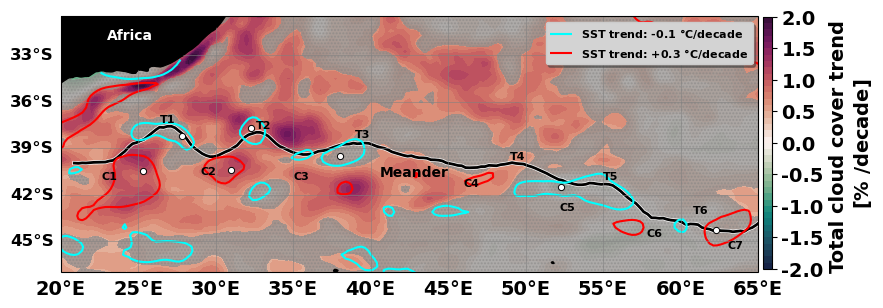

In [12]:
fig = plt.figure(figsize = (9,8))

####################### FIGURE 1
ax = [fig.add_subplot(grd[:50,:], projection=ccrs.PlateCarree())]

cf1 = ax[0].contourf(lon, lat, slope_decade, np.arange(-2,2.1,.1), cmap = cm.curl) 
ax[0].contourf(lon, lat, p_value, [0.05,1], cmap='gray', alpha = .4) 
cf_hatch = ax[0].contourf(lon, lat, p_value, [0.05,1], cmap='Greys',alpha=.5, hatches=['.....']) 
cf_hatch.set_edgecolor('grey')
cf_hatch.set_linewidth(0)

ax[0].plot(lon_front, lat_front_mean, color = 'w', linewidth = 3)
ax[0].plot(lon_front, lat_front_mean, color = 'k', linewidth = 2)


cr_SST = ax[0].contour(SST_lon, SST_lat, SST_trend, [-.1,.3], colors = ['cyan', 'red'], linestyles = 'solid')
handles_SST, labels_SST = cr_SST.legend_elements()
ax[0].legend(handles_SST, 
             [r'SST trend: -0.1 $\degree$C/decade', 'SST trend: +0.3 $\degree$C/decade'],
             loc = 'upper right', fontsize = 8, facecolor = 'lightgrey', shadow=True)

# tcc_trend = ax[0].contour(lon, lat, slope_decade, [-.2, 1], colors =['green', 'red']) 
# handles_, labels_ = tcc_trend.legend_elements()
# ax[0].legend(handles_, 
#              [r'TCC trend: -0.2 $\%$ /decade', 'TCC trend: +1 $\%$ /decade'],
#              loc = 'upper right', fontsize = 8, facecolor = 'lightgrey', shadow=True)

## Details
ax[0].annotate(text='Africa', color='w', xy=(23,-32), xycoords='data', fontsize = 10, zorder = 300)
ax[0].set_extent(extent, ccrs.PlateCarree())
ax[0].add_feature(cartopy.feature.COASTLINE)
ax[0].add_feature(cartopy.feature.LAND, facecolor='k', zorder=10)
gl = ax[0].gridlines(draw_labels = False, crs=ccrs.PlateCarree(), linewidth=0.4, color='grey')
gl.left_labels = True
gl.bottom_labels = True
gl.ylocator = mticker.FixedLocator(np.arange(-60, -30, 3))
gl.xlocator = mticker.FixedLocator(np.arange(10, 80, 5))
gl.ylabel_style = {'size': 12}

### Some annotation
ax[0].annotate(text='Meander', color='k', xy=(40.6,-40.8), xycoords='data', fontsize = 10, zorder = 300, fontweight = 'bold')
ft = 8
ax[0].annotate(text='C1', color='k', xy=(22.6,-41), xycoords='data', fontsize = ft, zorder = 300)
ax[0].annotate(text='T1', color='k', xy=(26.4,-37.35), xycoords='data', fontsize = ft, zorder = 300)
ax[0].annotate(text='C2', color='k', xy=(29,-40.7), xycoords='data', fontsize = ft, zorder = 300)
ax[0].annotate(text='T2', color='k', xy=(32.6,-37.7), xycoords='data', fontsize = ft, zorder = 300)
ax[0].annotate(text='C3', color='k', xy=(35,-41), xycoords='data', fontsize = ft, zorder = 300)
ax[0].annotate(text='T3', color='k', xy=(39,-38.3), xycoords='data', fontsize = ft, zorder = 300)
ax[0].annotate(text='C4', color='k', xy=(46,-41.5), xycoords='data', fontsize = ft, zorder = 300)
ax[0].annotate(text='T4', color='k', xy=(49,-39.7), xycoords='data', fontsize = ft, zorder = 300)
ax[0].annotate(text='C5', color='k', xy=(52.2,-43), xycoords='data', fontsize = ft, zorder = 300)
ax[0].annotate(text='T5', color='k', xy=(55,-41), xycoords='data', fontsize = ft, zorder = 300)
ax[0].annotate(text='C6', color='k', xy=(57.8,-44.7), xycoords='data', fontsize = ft, zorder = 300)
ax[0].annotate(text='T6', color='k', xy=(60.8,-43.2), xycoords='data', fontsize = ft, zorder = 300)
ax[0].annotate(text='C7', color='k', xy=(63,-45.5), xycoords='data', fontsize = ft, zorder = 300)

## Scatter
ax[0].scatter(lon_crest_1, lat_crest_1, s = 20, color = 'w', edgecolor = 'k', zorder = 50, linewidth=.7)
ax[0].scatter(lon_crest_2, lat_crest_2, s = 20, color = 'w', edgecolor = 'k', zorder = 50, linewidth=.7)
ax[0].scatter(lon_crest_4, lat_crest_4, s = 20, color = 'w', edgecolor = 'k', zorder = 50, linewidth=.7)
ax[0].scatter(lon_crest_7, lat_crest_7, s = 20, color = 'w', edgecolor = 'k', zorder = 50, linewidth=.7)
ax[0].scatter(lon_trough_1, lat_trough_1, s = 20, color = 'w', edgecolor = 'k', zorder = 50, linewidth=.7)
ax[0].scatter(lon_trough_2, lat_trough_2, s = 20, color = 'w', edgecolor = 'k', zorder = 50, linewidth=.7)
ax[0].scatter(lon_trough_3, lat_trough_3, s = 20, color = 'w', edgecolor = 'k', zorder = 50, linewidth=.7)

## Colorbar
bar = plt.axes([0.905, 0.532, 0.01, 0.315])
cbar = plt.colorbar(cf1, cax = bar, format = '%.1f')  
cbar.set_label('Total cloud cover trend \n' + '[$\%$ /decade]') 

# plt.savefig(path_fig + 'Fig_S2.jpg', dpi =300, bbox_inches = 'tight')

In [20]:
print('The trend and p-value of cloud cover at C1 is '+
str(round(float(slope_decade.interp(latitude = lat_crest_1, longitude = lon_crest_1)), 1)) + ' and ' +
str(round(float(p_value.interp(latitude = lat_crest_1, longitude = lon_crest_1)), 1)) + '\n'

'The trend and p-value of cloud cover at C2 is '+
str(round(float(slope_decade.interp(latitude = lat_crest_2, longitude = lon_crest_2)), 1)) + ' and ' +
str(round(float(p_value.interp(latitude = lat_crest_2, longitude = lon_crest_2)), 1))
      
     )

The trend and p-value of cloud cover at C1 is 1.0 and 0.0
The trend and p-value of cloud cover at C2 is 1.1 and 0.0


## Total cloud cover in 1/4$^\circ$ ERA5

In [4]:
# path = '/g/data/rt52/era5/single-levels/monthly-averaged/2t/'
# path = '/g/data/rt52/era5/single-levels/monthly-averaged-by-hour/2t/'
path = '/g/data/rt52/era5/single-levels/reanalysis/tcc/'
year = np.arange(1993,2020,1) 
files = np.array([])
## The files are in different directories
for i in range(len(year)):
    file = glob(path + str(year[i]) + '/*')
    file.sort()
    files = np.append(files, file)

In [ ]:
from functools import partial
def _preprocess(ds, lon_bnds, lat_bnds):
    return ds.sel(longitude = lon_bnds, latitude = lat_bnds)

yt_sel = slice(-30.5, -51)
xt_sel = slice(8, 76)
partial_func = partial(_preprocess, lon_bnds=xt_sel, lat_bnds=yt_sel)
data = xr.open_mfdataset(list(files), preprocess=partial_func)  

In [ ]:
time_sel = slice('1993-01-01', '2019-05-31')
cloud    = data.tcc.sel(time=time_sel)
cloud_daily = cloud.resample(time='1D').mean('time').compute()*100 ## I mulitply to a hundred to obtain in percentage
lon, lat = cloud.longitude, cloud.latitude

## Statistics

In [ ]:
slope   = np.random.rand(len(lat),len(lon))*np.nan
p_value = slope.copy()

In [ ]:
t = np.arange(len(cloud_daily))
for i in range(len(lat)):
    for j in range(len(lon)):
        slope[i,j], intercept, c_value, p_value[i,j], _ = stats.linregress(t, cloud_daily[:,i,j])

slope_decade = slope*(365*10 + 2)

In [ ]:
## saving this trend
ds = xr.Dataset(data_vars=dict(slope_decade_Ta = (["latitude", "longitude"], slope_decade),
                               p_value_Ta      = (["latitude", "longitude"], p_value)),
                        
                coords=dict(latitude=(["latitude"], lat.data),
                            longitude=(["longitude"], lon.data)),
                attrs=dict(description="Trend of total cloud cover between Jan 1993 and May 2019 [percentage decade-1]."))

path_save = '/g/data/jk72/fs3401/Desktop/Agulhas_meander/output/'
ds.to_netcdf(path_save+'cloud_trend_26years.nc')

## Figures

In [14]:
path_fig = '/g/data/jk72/fs3401/Desktop/Agulhas_meander/figures/'
props = dict(boxstyle='round', facecolor='w')
grd = GridSpec(100,100)

extent = [19.99, 65.01, -47, -30.5]
props = dict(boxstyle='round', facecolor='w', alpha=1)
outline = mpe.withStroke(linewidth=2, foreground='w')

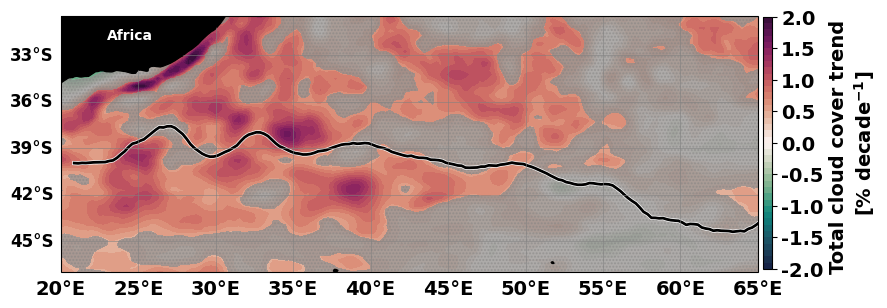

In [50]:
fig = plt.figure(figsize = (9,8))

####################### FIGURE 1
ax = [fig.add_subplot(grd[:50,:], projection=ccrs.PlateCarree())]

cf1 = ax[0].contourf(lon, lat, slope_decade, np.arange(-2,2.1,.1), cmap = cm.curl) 
ax[0].contourf(lon, lat, p_value, [0.05,1], cmap='gray', alpha = .4) 
cf_hatch = ax[0].contourf(lon, lat, p_value, [0.05,1], cmap='Greys',alpha=.5, hatches=['.....']) 
cf_hatch.collections[0].set_edgecolor('grey')
cf_hatch.collections[0].set_linewidth(0)

ax[0].plot(lon_front, lat_front_mean, color = 'w', linewidth = 3)
ax[0].plot(lon_front, lat_front_mean, color = 'k', linewidth = 2)

## Details
ax[0].annotate(text='Africa', color='w', xy=(23,-32), xycoords='data', fontsize = 10, zorder = 300)
ax[0].set_extent(extent, ccrs.PlateCarree())
ax[0].add_feature(cartopy.feature.COASTLINE)
ax[0].add_feature(cartopy.feature.LAND, facecolor='k', zorder=10)
gl = ax[0].gridlines(draw_labels = False, crs=ccrs.PlateCarree(), linewidth=0.4, color='grey')
gl.left_labels = True
gl.bottom_labels = True
gl.ylocator = mticker.FixedLocator(np.arange(-60, -30, 3))
gl.xlocator = mticker.FixedLocator(np.arange(10, 80, 5))
gl.ylabel_style = {'size': 12}

## Colorbar
bar = plt.axes([0.905, 0.532, 0.01, 0.315])
cbar = plt.colorbar(cf1, cax = bar, format = '%.1f')  
cbar.set_label('Total cloud cover trend \n' + '[$\%$ decade$^{-1}$]') 

plt.savefig(path_fig + 'Fig_S1.jpg', dpi =300, bbox_inches = 'tight')

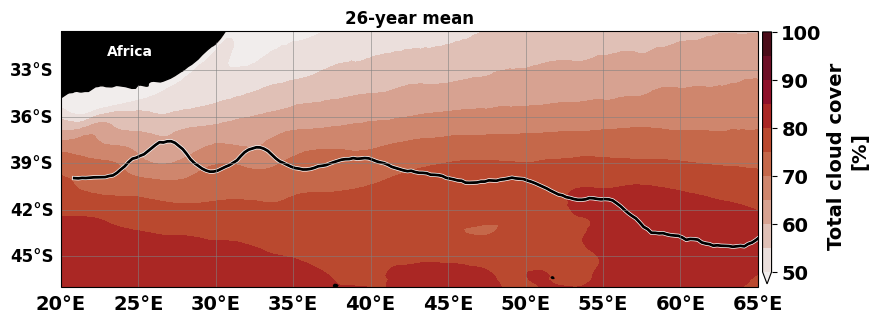

In [71]:
fig = plt.figure(figsize = (9,8))

####################### FIGURE 1
ax = [fig.add_subplot(grd[:50,:], projection=ccrs.PlateCarree())]

cf1 = ax[0].contourf(lon, lat, cloud_daily.mean('time')*100, np.arange(50,105,5), cmap = cm.amp, extend = 'min') 

ax[0].plot(lon_front, lat_front_mean, color = 'w', linewidth = 3)
ax[0].plot(lon_front, lat_front_mean, color = 'k', linewidth = 2)

## Details
ax[0].annotate(text='Africa', color='w', xy=(23,-32), xycoords='data', fontsize = 10, zorder = 300)
ax[0].set_extent(extent, ccrs.PlateCarree())
ax[0].add_feature(cartopy.feature.COASTLINE)
ax[0].add_feature(cartopy.feature.LAND, facecolor='k', zorder=10)
gl = ax[0].gridlines(draw_labels = False, crs=ccrs.PlateCarree(), linewidth=0.4, color='grey')
gl.left_labels = True
gl.bottom_labels = True
gl.ylocator = mticker.FixedLocator(np.arange(-60, -30, 3))
gl.xlocator = mticker.FixedLocator(np.arange(10, 80, 5))
gl.ylabel_style = {'size': 12}

## Colorbar
bar = plt.axes([0.905, 0.532, 0.01, 0.315])
cbar = plt.colorbar(cf1, cax = bar, format = '%.0f')  
cbar.set_label('Total cloud cover \n' + '[$\%$]') 
ax[0].set_title('26-year mean', fontsize = 12)

plt.savefig(path_fig + 'Fig_mean_clouds.jpg', dpi =300, bbox_inches = 'tight')

In [70]:
75/2

37.5